# Time Evolution of the Lindblad Equation for the Schwinger Model
**Ultimate Goal**: Prepare a thermal state
$$e^{- \beta H} / Z$$
approximately for a large system.

## Basic Imports

In [12]:
# For circuit setup
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate

# For transpilation
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# For backends and running circuits via Estimator or Sample
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService

# For math and data analysis
import math
import numpy as np
from numpy import pi
from matplotlib import pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

## Backend Setup

In [13]:
from qiskit_aer import AerSimulator # noiseless simualtor
backend = AerSimulator()

## Transpiler Setup

In [14]:
pm = generate_preset_pass_manager(backend=backend, optimization_level = 2)

## Estimator Setup

In [15]:
estimator = Estimator(backend)

## Schwinger Hamiltonian
The following function creates the Schwinger model Hamitlonian as a SparsePauliOp.
$$H = H_{kin} + H_{mass} + H_{elec}$$
where
$$H_{kin} \equiv \frac{1}{2a} \sum_{i = 0}^{L - 2} (\sigma_i^{+} \sigma_{i+1}^{-} + \sigma_{i+1}^{+} \sigma_i^{-})$$
$$H_{mass} \equiv m \sum_{i=0}^{L-1} O_i, O_i \equiv (-1)^i \frac{\sigma_i^z + 1}{2a}$$
$$H_{elec} \equiv \frac{a}{2} \sum_{i=0}^L E_i^2, E_i \equiv e(l_0 + \frac{1}{2} \sum_{j=0}^{i-1}(\sigma_j^z + (-1)^j)$$

a: lattice space

n: index of lattice position $x = na$

L: number of qubits

$\sigma^{\pm} = (\sigma_x \pm i\sigma_y)/2)$: creation/annihilation operators

We set $l_0 = 0$.

In [16]:
def get_schwinger_hamiltonian(L: int, m: float, e: float, a: float, include_shifts: bool = True) -> SparsePauliOp:
    if L <= 0:
        raise ValueError("L must be >= 1.")
    if a == 0:
        raise ValueError("a must be nonzero.")

    terms = []

    # Kinetic term
    ## H_kin = sum_{i=0}^{L-2} (1/(4a)) (X_i X_{i+1} + Y_i Y_{i+1})
    kin_coeff = 1.0 / (4.0 * a)
    for i in range(L - 1):
        terms.append(("XX", [i, i + 1], kin_coeff))
        terms.append(("YY", [i, i + 1], kin_coeff))

    # Mass term
    ## H_mass = sum_i m * (-1)^i * (Z_i + I)/(2a)
    for i in range(L):
        coeff = m * ((-1) ** i) / (2.0 * a)
        terms.append(("Z", [i], coeff))
        if include_shifts: # global energy shift
            terms.append(("I", [0], coeff))

    # Electric term
    ## E_i = (e/2) (S_i + C_i),  S_i = sum_{j<i} Z_j,  C_i = sum_{j<i} (-1)^j
    ## E_i^2 = (e^2/4) [ S_i^2 + 2 C_i S_i + C_i^2 ]
    ## S_i^2 = i*I + 2 sum_{j<k<i} Z_j Z_k
    base_I = (a / 2.0) * (e**2 / 4.0)
    zz_coeff = (a * e**2) / 4.0
    z_per_link_unit = (a * e**2) / 4.0

    for i in range(1, L + 1):
        # C_i = sum_{j=0}^{i-1} (-1)^j = 1 if i is odd else 0
        C = i % 2

        # Identity from i*I + C^2*I
        if include_shifts:
            terms.append(("I", [0], base_I * (i + C))) # since C^2 = C for C in {0, 1}

        # linear Z terms: (a/2)*(e^2/4)*(2 C) * sum_{j<i} Z_j = (a e^2/4)*C * sum_{j<i} Z_j
        if C == 1:
            for j in range(i):
                terms.append(("Z", [j], z_per_link_unit))

        # ZZ terms: (a/2)*(e^2/4)*(2) * sum_{j<k<i} Z_j Z_k = (a e^2/4) * sum_{j<k<i} Z_j Z_k
        for j in range(i):
            for k in range(j + 1, i):
                terms.append(("ZZ", [j, k], zz_coeff))

    H = SparsePauliOp.from_sparse_list(terms, num_qubits=L)
    return H.simplify()

In [17]:
def sparse_mat(op: SparsePauliOp) -> sp.csr_matrix: # converts a SparsePauliOp to a matrix
    return op.to_matrix(sparse=True)

### Checking Hamiltonian construction

In [18]:
# Parameters
L = 6
a = 1.0
m = 0.5
e = 1.0

H = get_schwinger_hamiltonian(L, m, e, a)
H_dense = H.to_matrix()

vals_all = np.linalg.eigvals(H_dense)
vals_all = np.real_if_close(vals_all, tol=1e5)  # removes tiny imaginary parts if present
vals_all = np.asarray(vals_all, dtype=np.complex128)
vals_all

array([ 2.20385406+0.j,  3.17706422+0.j,  4.09554717+0.j,  4.41861399+0.j,
        5.77348826+0.j,  6.83143231+0.j, 12.07124027+0.j,  7.8564808 +0.j,
        8.77915666+0.j,  6.84784252+0.j,  7.75458251+0.j,  5.47470321+0.j,
       -2.17935655+0.j,  6.37383893+0.j, -0.43062036+0.j,  4.50897349+0.j,
        5.19403296+0.j,  4.29488609+0.j,  3.73903943+0.j, -1.06201148+0.j,
        3.4280484 +0.j,  4.60846576+0.j,  4.32714866+0.j,  4.10795759+0.j,
        3.87675283+0.j, -0.45117005+0.j,  0.50902446+0.j, -0.36291496+0.j,
       -0.22088833+0.j,  2.57736812+0.j,  2.53636296+0.j,  3.32407732+0.j,
       -0.06897418+0.j, -0.02267936+0.j, -0.04709256+0.j,  3.08824238+0.j,
        1.28079586+0.j,  2.91339512+0.j,  1.441233  +0.j,  2.71617821+0.j,
        1.64410997+0.j,  2.6735862 +0.j,  0.80051069+0.j,  0.69516238+0.j,
        0.64717163+0.j,  0.64799083+0.j,  0.88592822+0.j,  0.90025545+0.j,
        1.11042683+0.j,  1.17745058+0.j,  1.79175206+0.j,  1.40791377+0.j,
        1.52841255+0.j,  

In [19]:
# Comparing with given eigenvalues
given = np.asarray([-2.17935655, -0.45117005, -0.36291496, -0.22088833, -0.06897418, -0.02267936,
  0.64717163,  0.64799083,  0.80051069,  1.40791377,  1.52841255,  1.69044329,
  1.79807205,  1.86945912,  1.92068802,  2.12033848,  2.6735862,   2.71617821,
  3.87675283,  4.60846576], dtype=np.complex128)

def format_c(z: complex, prec=8):
    return f"{z.real:.{prec}e}{z.imag:+.{prec}e}j"

remaining = list(range(len(vals_all)))
ordered = []

for lam in given:
    # finding nearest among remaining
    rem_vals = vals_all[remaining]
    j = int(np.argmin(np.abs(rem_vals - lam)))
    idx = remaining.pop(j)
    ordered.append(vals_all[idx])

ordered = np.array(ordered, dtype = np.complex128)
for z in ordered:
    print(format_c(z, prec=8))

-2.17935655e+00+0.00000000e+00j
-4.51170055e-01+0.00000000e+00j
-3.62914957e-01+0.00000000e+00j
-2.20888333e-01+0.00000000e+00j
-6.89741845e-02+0.00000000e+00j
-2.26793560e-02+0.00000000e+00j
6.47171627e-01+0.00000000e+00j
6.47990832e-01+0.00000000e+00j
8.00510689e-01+0.00000000e+00j
1.40791377e+00+0.00000000e+00j
1.52841255e+00+0.00000000e+00j
1.69044329e+00+0.00000000e+00j
1.79807205e+00+0.00000000e+00j
1.86945912e+00+0.00000000e+00j
1.92068802e+00+0.00000000e+00j
2.12033848e+00+0.00000000e+00j
2.67358620e+00+0.00000000e+00j
2.71617821e+00+0.00000000e+00j
3.87675283e+00+0.00000000e+00j
4.60846576e+00+0.00000000e+00j


## Liouvillian Operator
The Lindblad master equation for $\rho_S$ (system density matrix) can be written as:
$$\frac{d\rho_S(t)}{dt} = -i[H_S, \rho_S(t)] + a^2 \sum_{x_1, x_2} D(x_1 - x_2) \times (L(x_2)\rho_SL^{\dagger}(x_1) - \frac{1}{2} \{L^{\dagger}(x_1)L(x_2), \rho_S\}).$$

$D(x_1 - x_2)$: environment correlator

$L(na) = O(n) - \frac{1}{4T} [H_S, O(n)]$: Lindblad operators

$O(n) = (-1)^n \frac{\sigma_z(n) + 1}{2a}$

The Lindblad master equation can be written in terms of a Liouvillian superoperator as:
$$\frac{d \rho}{dt} \equiv \mathcal{L} \rho.$$

In [20]:
def O_n(n: int, L: int, a: float) -> SparsePauliOp:
    """
    n: site
    L: number of sites
    """
    s = (-1)**n

    I_label = "I" * L

    chars = ["I"] * L
    chars[-1 - n] = "Z" # rightmost is qubit 0
    Z_label = "".join(chars)

    O = SparsePauliOp.from_list([
        (I_label, s/(2.0*a)),
        (Z_label, s/(2.0*a)),
    ])

    return O.simplify()

In [21]:
def L_n(n: int, H: SparsePauliOp, L: int, a: float, T: float) -> SparsePauliOp:
    O = O_n(n, L, a)
    comm = H @ O - O @ H

    return (O - (1.0/(4.0*T)) * comm).simplify()

### Environment Correlator $D(x)$
Regarding the environmental correlator, $x_1 = n_1 a$ and $x_2 = n_2 a$ are discrete spatial coordinates.

For short range correlations, use a delta function:
$$D_{\delta}(x) = D_0 \delta_{0x}.$$

For intermediate-range correlations, use a Gaussian:
$$D_G(x) = D_0 \exp(-\frac{x^2}{2\sigma^2}) \equiv D_0 G(x, \sigma).$$

For long-range correlations, use a constant function:
$$D_C(x) = D_0.$$

In [22]:
def D_matrix(L: int, a: float, kind: str, D0: float, sigma: float | None = None):
    D = np.zeros((L, L), dtype = float)
    for n1 in range(L):
        for n2 in range(L):
            x = (n1 - n2) * a
            if kind == "delta":
                D[n1, n2] = D0 if n1 == n2 else 0.0
            elif kind == "gaussian":
                assert sigma is not None
                D[n1, n2] = D0 * np.exp(-(x*x) / (2.0*sigma*sigma))
            elif kind == "const":
                D[n1, n2] = D0
            else:
                raise ValueError("kind must be delta/gaussian/const")
    return D

### Now building the Liouvillian superoperator
In building the Liouvillian superoperator, the following ways of rewriting the Lindblad equation are used:

For the Hamiltonian part,
$$-i[H, \rho] \rightarrow -i (I \otimes H - H^T \otimes I) vec(\rho)$$

For the dissipator part,
$$a^2 \sum_{x_1, x_2} D(x_1 - x_2) [(L^{\dagger}(x_1))^T \otimes L(x_2) - \frac{1}{2}(I \otimes M) - \frac{1}{2} (M^T \otimes I)] vec(\rho)$$
where $M = L^{\dagger}(x_1)L(x_2).$

We can do this thanks to the following identity:
$$vec(A \rho B) = (B^T \otimes A) vec(\rho).$$

This way, the Lindblad equation is a linear ODE:
$$\frac{d}{dt}|\rho> = \mathcal{L}|\rho>$$

In [23]:
def build_liouvillian(H_op: SparsePauliOp, L_ops: list[SparsePauliOp], D: np.ndarray, a_lat: float) -> sp.csr_matrix:
    H = sparse_mat(H_op).tocsr()
    d = H.shape[0]
    I = sp.identity(d, format="csr")

    # -i [H, ρ]  ->  -i (I⊗H - H^T⊗I) vec(ρ)
    Lsuper = -1j * (sp.kron(I, H, format = "csr") - sp.kron(H.T, I, format = "csr"))

    Lmats = [sparse_mat(Lop).tocsr() for Lop in L_ops] # Lindblad matrices

    # Dissipator: a^2 sum_{n1,n2} D_{n1n2} ( L(n2) ρ L†(n1) - 1/2 {L†(n1)L(n2), ρ} )
    pref = (a_lat**2)
    for n1 in range(len(Lmats)):
        L1 = Lmats[n1]
        L1dag = L1.getH()
        L1star = L1.conjugate() # (L†)^T == L*

        for n2 in range(len(Lmats)):
            w = pref * D[n1, n2]
            if w == 0.0:
                continue

            L2 = Lmats[n2]
            M = (L1dag @ L2).tocsr()

            term_jump = sp.kron(L1star, L2, format = "csr")
            term_ac1 = sp.kron(I, M, format = "csr")
            term_ac2 = sp.kron(M.T, I, format = "csr")

            Lsuper += w * (term_jump - 0.5 * term_ac1 - 0.5*term_ac2)

    return Lsuper.tocsr()

### Checking Liouvillian superoperator construction

In [24]:
# Parameters
L = 4
a_lat = 1.0
T = 5.0
m = 0.5
e = 0.71

H = get_schwinger_hamiltonian(L, m, e, a_lat)

L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]

D = D_matrix(L, a_lat, kind="const", D0 = 1.0)

Lsuper = build_liouvillian(H, L_ops, D, a_lat)
Ld = Lsuper.toarray()

vals = np.linalg.eigvals(Ld)
vals = sorted(vals, key = lambda z: z.real, reverse = True)

In [25]:
# Comparing with given eigenvalues
vals_all = np.linalg.eigvals(Lsuper.toarray())

given = np.asarray([
    -3.27165339e-17+1.84374375e-17j, -9.24271504e-17+1.23084462e-16j,
    -5.49683823e-02-4.47083132e-01j, -5.49683823e-02+4.47083132e-01j,
    -6.06370298e-02+1.28174296e-02j, -6.06370298e-02-1.28174296e-02j,
    -1.07540816e-01+4.64566856e-01j, -1.07540816e-01-4.64566856e-01j,
    -1.08535026e-01-9.99650752e-17j, -1.65308941e-01+8.96133803e-17j,
    -3.13915019e-01-6.79522482e-17j, -4.17773467e-01-6.25506542e-16j,
    -4.60634662e-01+3.60048712e-02j, -4.60634662e-01-3.60048712e-02j,
    -4.77113769e-01-3.74875107e-01j, -4.77113769e-01+3.74875107e-01j,
    -1.05896504e+00-1.24389324e-15j, -1.47677327e+00-1.94707262e+00j,
    -1.47677327e+00+1.94707262e+00j, -1.48778673e+00+1.45821468e-17j,
    -1.53058783e+00+1.65481866e+00j, -1.53058783e+00-1.65481866e+00j,
    -1.65265405e+00+1.89292675e+00j, -1.65265405e+00-1.89292675e+00j,
    -1.68118664e+00-1.40596425e+00j, -1.68118664e+00+1.40596425e+00j,
    -1.68583228e+00+1.16965604e+00j, -1.68583228e+00-1.16965604e+00j,
    -1.74045706e+00-1.46933933e+00j, -1.74045706e+00+1.46933933e+00j,
    -1.75757329e+00-1.51180342e+00j, -1.75757329e+00+1.51180342e+00j,
    -1.87056050e+00-1.36547776e+00j, -1.87056050e+00+1.36547776e+00j,
    -7.75733831e+00+2.55247828e+00j, -7.75733831e+00-2.55247828e+00j
], dtype=np.complex128)

def format_c(z: complex, prec=8):
    return f"{z.real:.{prec}e}{z.imag:+.{prec}e}j"

vals_all = np.asarray(np.linalg.eigvals(Lsuper.toarray()), dtype = np.complex128)

remaining = list(range(len(vals_all)))
ordered = []

for lam in given:
    # finding nearest among remaining
    rem_vals = vals_all[remaining]
    j = int(np.argmin(np.abs(rem_vals - lam)))
    idx = remaining.pop(j)
    ordered.append(vals_all[idx])

ordered = np.array(ordered, dtype = np.complex128)
for z in ordered:
    print(format_c(z, prec=8))

0.00000000e+00+0.00000000e+00j
0.00000000e+00+0.00000000e+00j
-5.49683823e-02-4.47083132e-01j
-5.49683823e-02+4.47083132e-01j
-6.06370298e-02+1.28174296e-02j
-6.06370298e-02-1.28174296e-02j
-1.07540816e-01+4.64566856e-01j
-1.07540816e-01-4.64566856e-01j
-1.08535026e-01-8.46920449e-16j
-1.65308941e-01-7.20312881e-16j
-3.13915019e-01-4.36101958e-16j
-4.17773467e-01-3.32741647e-16j
-4.60634662e-01+3.60048712e-02j
-4.60634662e-01-3.60048712e-02j
-4.77113769e-01-3.74875107e-01j
-4.77113769e-01+3.74875107e-01j
-1.05896504e+00-8.26625220e-16j
-1.47677327e+00-1.94707262e+00j
-1.47677327e+00+1.94707262e+00j
-1.48778673e+00+2.09896398e-16j
-1.53058783e+00+1.65481866e+00j
-1.53058783e+00-1.65481866e+00j
-1.65265405e+00+1.89292675e+00j
-1.65265405e+00-1.89292675e+00j
-1.68118664e+00-1.40596425e+00j
-1.68118664e+00+1.40596425e+00j
-1.68583228e+00+1.16965604e+00j
-1.68583228e+00-1.16965604e+00j
-1.74045706e+00-1.46933933e+00j
-1.74045706e+00+1.46933933e+00j
-1.75757329e+00-1.51180342e+00j
-1.7575732

## Building J Operator
The quantum circuit below reproduces the Lindblad equation when $\Delta t \rightarrow 0$.
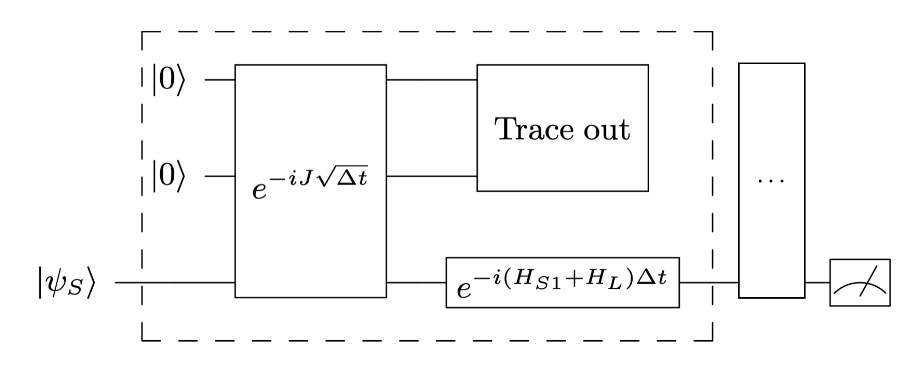

Here, J is defined as:
$$\begin{pmatrix} 0 & L_1^{\dagger} & ... & L_m^{\dagger} \\ L_1 & 0 & ... & 0 \\ \vdots & \vdots &  & \vdots \\ L_m & 0 & ... & 0 \end{pmatrix}$$

where the $L$'s are the Lindblad operators defined previously.

The $|0\rangle$ qubits are auxiliary qubits that help simulate the non-unitary evolution of the Lindblad equation. Adding these auxiliary qubits makes the whole system evolve unitarily. They are traced out after every time step.

In [26]:
def int_to_bits(idx: int, nbits: int) -> list[int]:
    """
    Extracts an integer's binary digits as a list of 0/1 values.
    """
    if idx < 0 or idx >= (1 << nbits):
        raise ValueError(f"idx = {idx} out of range for nbits = {nbits}")
    return [(idx >> q) & 1 for q in range(nbits)] # q = 0 is qubit 0

def int_to_bitstring(idx: int, nbits: int) -> str:
    """
    Converts an integer to binary as a string.
    """
    bits = int_to_bits(idx, nbits)
    return "".join(str(bits[q]) for q in reversed(range(nbits)))

In [27]:
# Checking int_to_bits and int_to_bitstring
binary_list = int_to_bits(3, 4)
print(binary_list)

print(int_to_bitstring(3, 4))

[1, 1, 0, 0]
0011


In [28]:
def ketbra_1q(ket: int, bra: int) -> SparsePauliOp:
    """
    |0><0| = 0.5(I + Z)
    |1><1| = 0.5(I - Z)
    |0><1| = 0.5(X + iY)
    |1><0| = 0.5(X - iY)
    """
    if ket == 0 and bra == 0:
        return SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
    if ket == 1 and bra == 1:
        return SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])
    if ket == 0 and bra == 1:
        return SparsePauliOp.from_list([("X", 0.5), ("Y", 0.5j)])
    if ket == 1 and bra == 0:
        return SparsePauliOp.from_list([("X", 0.5), ("Y", -0.5j)])
    raise ValueError("ket and bra must be 0 or 1")

def ketbra_from_bits(ket_bits: list[int], bra_bits: list[int]) -> SparsePauliOp:
    """
    Returns a SparsePauliOp for |ket><bra| on n qubits.
    ket_bits[q] corresponds to qubit q

    |ket><bra| = ⊗_{q=0}^{n-1} (|k_q><b_q|)
    """
    if len(ket_bits) != len(bra_bits):
        raise ValueError("ket_bits and bra_bits must have same length")
    n = len(ket_bits)
    if n == 0:
        raise ValueError("Need at least 1 qubit")

    op = ketbra_1q(ket_bits[n-1], bra_bits[n-1])
    for q in reversed(range(n-1)): # q = n-2 ... 0
        op = op.tensor(ketbra_1q(ket_bits[q], bra_bits[q]))
    return op.simplify()

def ketbra_from_ints(ket: int, bra: int, nbits: int) -> SparsePauliOp:
    """
    Straight from an integer to a tensor product.
    """
    return ketbra_from_bits(int_to_bits(ket, nbits), int_to_bits(bra, nbits))

In [29]:
# Checking functions
ket_bits = [1, 0] # qubit 0 is 1, qubit 1 is 0
bra_bits = [0, 1]

op = ketbra_from_bits(ket_bits = ket_bits, bra_bits = bra_bits)
M = op.to_matrix()
print(M)

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


In [30]:
def build_J_operator(L_ops: list[SparsePauliOp], n_sys: int) -> SparsePauliOp:
    """
    J = sum_{j=1}^m ( |j><0| ⊗ L_j + |0><j| ⊗ L_j^† )
    """
    m = len(L_ops)
    n_aux = math.ceil(math.log2(m+1))
    if (1 << n_aux) < (m + 1):
        raise ValueError("n_aux sizing failed")

    total_qubits = n_aux + n_sys
    J = SparsePauliOp.from_list([("I" * total_qubits, 0.0)])

    for j, Lj in enumerate(L_ops, start=1):
        if j > m:
            break

        ket_j_bra_0 = ketbra_from_ints(j, 0, n_aux) # |j><0|
        ket_0_bra_j = ketbra_from_ints(0, j, n_aux) # |0><j|

        Lj_dag = Lj.adjoint()

        J += ket_j_bra_0.tensor(Lj)
        J += ket_0_bra_j.tensor(Lj_dag)

    return J.simplify()

### Checking J Operator Construction
Block (j, 0) in the aux basis should equal $L_j$, and block (0, j) should equal $L^{\dagger}_j$ with all other blocks zero.

The block structure should match:
$$J[j,0] = L_j$$
$$J[0,j] = L^{\dagger}_j$$

In [31]:
def check_J_blocks(J: SparsePauliOp, L_ops: list[SparsePauliOp], n_sys: int):
    m = len(L_ops)
    n_aux = J.num_qubits - n_sys
    d_aux = 2**n_aux
    d_sys = 2**n_sys

    Jm = J.to_matrix()
    Lmats = [L.to_matrix() for L in L_ops]

    def block(a, b):
        # aux block (a, b)
        r0, r1 = a*d_sys, (a+1)*d_sys
        c0, c1 = b*d_sys, (b+1)*d_sys
        return Jm[r0:r1, c0:c1]

    # Checking |j><0| blocks
    for j in range(1, m+1):
        err = np.linalg.norm(block(j, 0) - Lmats[j-1])
        print(f"||J[{j},0] - L_{j}|| =", err)

    # Checking |0><j| blocks
    for j in range(1, m+1):
        err = np.linalg.norm(block(0, j) - Lmats[j-1].conj().T)
        print(f"||J[0,{j}] - L_{j}^†|| =", err)

In [32]:
L = 4
a_lat = 1.0
m_mass = 0.5
e_coup = 0.71
T = 5.0
    
H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
    
J = build_J_operator(L_ops = L_ops, n_sys = H.num_qubits)

check_J_blocks(J, L_ops, n_sys = H.num_qubits)

||J[1,0] - L_1|| = 9.813077866773595e-18
||J[2,0] - L_2|| = 1.3877787807814457e-17
||J[3,0] - L_3|| = 1.3877787807814457e-17
||J[4,0] - L_4|| = 9.813077866773595e-18
||J[0,1] - L_1^†|| = 9.813077866773595e-18
||J[0,2] - L_2^†|| = 1.3877787807814457e-17
||J[0,3] - L_3^†|| = 1.3877787807814457e-17
||J[0,4] - L_4^†|| = 9.813077866773595e-18


## Quantum Circuit